# Camera Pose Optimization (Single-Frame GS)

This notebook reproduces the RTSGS projection pipeline for a single keyframe, trains the Gaussians on that frame,
and then optimizes the pose of a second frame using gradients through the renderer.

Scene: Replica room1 (same as main.py).

In [248]:
import os
import numpy as np
import cv2
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from RTSGS.Config.ReplicaConfig import ReplicaConfig
from RTSGS.DataLoader.ReplicaDataLoader import ReplicaDataLoader
from RTSGS.Tracker.ProjectedPointToPlaneTracker import ProjectedPointToPlaneTracker
from RTSGS.GaussianSplatting.PointCloud import PointCloud
from RTSGS.GaussianSplatting.GaussianSplating import GaussianSplatting, frustum_cull_mask, _build_K
from gsplat import rendering, spherical_harmonics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [249]:
# Load the same Replica scene as main.py
data_path = "./Datasets/Replica/ThirdParty/Replica/room1/results"
trajectory_path = "./Datasets/Replica/ThirdParty/Replica/room1/traj.txt"

# Pick the target frame index you want to optimize (must be < len(data.RGBD_pairs))
frame1_idx = 50

data = ReplicaDataLoader(data_path=data_path, trajectory_path=trajectory_path)
data.load_data(limit=100)

assert frame1_idx < len(data.RGBD_pairs), f"frame1_idx={frame1_idx} out of range (len={len(data.RGBD_pairs)})"


def sanitize_pose(T):
    T = np.asarray(T, dtype=np.float32)
    if T.shape != (4, 4) or (not np.isfinite(T).all()):
        return np.eye(4, dtype=np.float32)
    R = T[:3, :3]
    if abs(np.linalg.det(R)) < 1e-8:
        return np.eye(4, dtype=np.float32)
    T = T.copy()
    T[3, :] = np.array([0.0, 0.0, 0.0, 1.0], dtype=np.float32)
    return T


assert len(data.RGBD_pairs) >= 2, "Need at least 2 RGB-D frames."
assert data.gt_poses is not None, "Replica trajectory missing: check traj.txt path."

rgb0_path, depth0_path = data.RGBD_pairs[0]
rgb1_path, depth1_path = data.RGBD_pairs[frame1_idx]

rgb0 = cv2.imread(rgb0_path, cv2.IMREAD_COLOR)
depth0 = cv2.imread(depth0_path, cv2.IMREAD_UNCHANGED).astype(np.float32)

rgb1 = cv2.imread(rgb1_path, cv2.IMREAD_COLOR)
depth1 = cv2.imread(depth1_path, cv2.IMREAD_UNCHANGED).astype(np.float32)

pose0 = sanitize_pose(data.gt_poses[0])
pose1_gt = sanitize_pose(data.gt_poses[frame1_idx])

print("frame1_idx:", frame1_idx)
print("rgb0:", rgb0.shape, "depth0:", depth0.shape)
print("rgb1:", rgb1.shape, "depth1:", depth1.shape)

Loaded 100 RGB-D pairs.
Loaded 100 ground truth poses.
frame1_idx: 50
rgb0: (680, 1200, 3) depth0: (680, 1200)
rgb1: (680, 1200, 3) depth1: (680, 1200)


In [250]:
# Initialize RTSGS components
config = ReplicaConfig()
tracker = ProjectedPointToPlaneTracker(dataset=data, config=config)
pcd = PointCloud(config)
gs = GaussianSplatting(pcd, data, tracker, max_steps_per_sec=5000, downsample_factor=2.0)

pcd.set_rendered_depth_provider(gs.render_depth_at_pose)
tracker.set_rendered_depth_provider(gs.render_depth_at_pose)
tracker.set_rendered_rgb_provider(gs.render_rgb_at_pose)

print("train size (HxW):", gs.train_height, gs.train_width)

train size (HxW): 340 600


In [251]:
# Project multiple past frames into Gaussians to increase map coverage.
# Using only one keyframe often makes pose poorly observable for distant frames.

map_frame_indices = list(range(0, min(frame1_idx, 20), 2))  # e.g., 0,2,4,... (exclude target frame)
if len(map_frame_indices) == 0:
    map_frame_indices = [0]

# IMPORTANT: reset map state when rebuilding, otherwise novelty/depth filtering can remove all points.
pcd.all_points = None
pcd.all_sh = None
pcd.all_scales = None
pcd.all_quaternions = None
pcd.all_alpha = None

# Seed map without rendered-depth novelty filtering (the map is empty anyway).
old_provider = getattr(pcd, "rendered_depth_provider", None)
pcd.set_rendered_depth_provider(None)

data.rgb_keyframes = []
data.depth_keyframes = []
data.current_keyframe_index = 0
tracker.keyframes_poses = []

added_total = 0
for kf_idx in map_frame_indices:
    rgb_path, depth_path = data.RGBD_pairs[kf_idx]
    rgb_kf = cv2.imread(rgb_path, cv2.IMREAD_COLOR)
    depth_kf = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)
    assert rgb_kf is not None, f"Failed to read RGB for frame {kf_idx}: {rgb_path}"
    assert depth_kf is not None, f"Failed to read depth for frame {kf_idx}: {depth_path}"
    depth_kf = depth_kf.astype(np.float32)
    pose_kf = sanitize_pose(data.gt_poses[kf_idx])

    new_data = pcd.process_single_keyframe(rgb_kf, depth_kf, pose_kf)
    if new_data is None:
        print(f"[warn] No Gaussians generated for frame {kf_idx} (skipping)")
        continue
    pcd._merge_data(new_data)
    added_total = int(pcd.all_points.shape[0])

    data.rgb_keyframes.append(rgb_kf)
    data.depth_keyframes.append(depth_kf)
    tracker.keyframes_poses.append(pose_kf)
    data.current_keyframe_index += 1

# Restore provider for later novelty filtering / downstream ops.
pcd.set_rendered_depth_provider(old_provider)

print("map_frame_indices:", map_frame_indices)
print("seeded keyframes:", len(tracker.keyframes_poses))
print("num gaussians:", int(pcd.all_points.shape[0]) if pcd.all_points is not None else 0)

map_frame_indices: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
seeded keyframes: 10
num gaussians: 26369


loss start/end: 0.005977049004286528 0.0028035035356879234


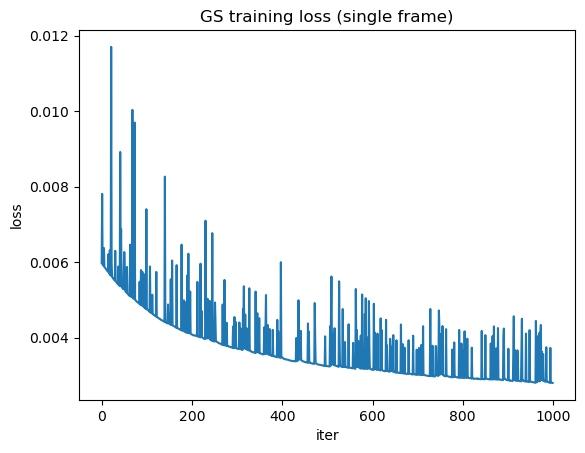

In [263]:
# Train Gaussians on the single keyframe
gs.step_limiter.rate = 1e9
losses = []

for _ in range(1000):
    loss = gs.training_step()
    losses.append(loss)

print("loss start/end:", losses[0], losses[-1])
plt.plot(losses)
plt.title("GS training loss (single frame)")
plt.xlabel("iter")
plt.ylabel("loss")
plt.show()

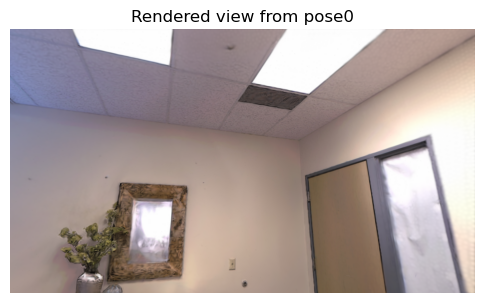

In [264]:
# Quick sanity render from the trained pose
render0 = gs.render_rgb_at_pose(pose0)

if render0 is None:
    print("Render failed (no Gaussians or invalid pose).")
else:
    plt.figure(figsize=(6, 4))
    plt.imshow(cv2.cvtColor(render0, cv2.COLOR_BGR2RGB))
    plt.title("Rendered view from pose0")
    plt.axis("off")
    plt.show()

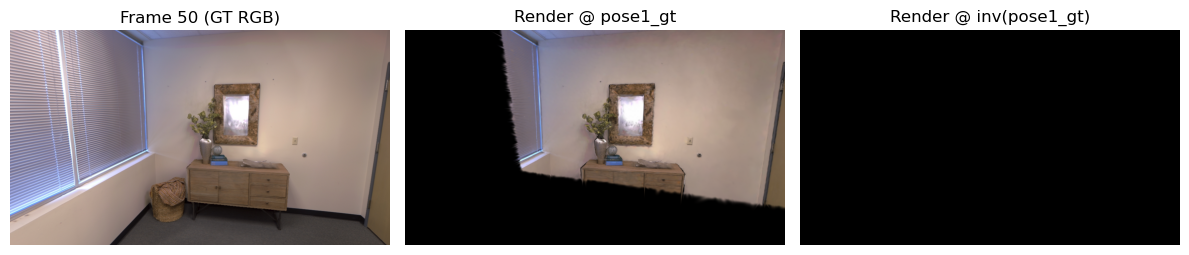

In [265]:
# Sanity-check pose convention on the target frame:
# We render using pose1_gt and also its inverse, and visually compare to rgb1.
render_gt = gs.render_rgb_at_pose(pose1_gt)
render_gt_inv = gs.render_rgb_at_pose(np.linalg.inv(pose1_gt))

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(rgb1, cv2.COLOR_BGR2RGB))
plt.title(f"Frame {frame1_idx} (GT RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
if render_gt is None:
    plt.title("Render @ pose1_gt (None)")
else:
    plt.imshow(cv2.cvtColor(render_gt, cv2.COLOR_BGR2RGB))
    plt.title("Render @ pose1_gt")
plt.axis("off")

plt.subplot(1, 3, 3)
if render_gt_inv is None:
    plt.title("Render @ inv(pose1_gt) (None)")
else:
    plt.imshow(cv2.cvtColor(render_gt_inv, cv2.COLOR_BGR2RGB))
    plt.title("Render @ inv(pose1_gt)")
plt.axis("off")

plt.tight_layout()
plt.show()

## Pose Optimization for Frame 2

We optimize a small SE(3) delta so that the rendered image/depth matches frame 2.

The gradient flows from the photometric/depth loss back to the pose parameters.

In [266]:
# Pose update convention:
# - "right" : T_new = T_init @ exp(xi)  (xi in camera/body frame)
# - "left"  : T_new = exp(xi) @ T_init  (xi in world/spatial frame)
POSE_UPDATE_MODE = "left"

def _skew(w):
    wx, wy, wz = w[0], w[1], w[2]
    z = torch.zeros_like(wx)
    return torch.stack([
        torch.stack([z, -wz, wy]),
        torch.stack([wz, z, -wx]),
        torch.stack([-wy, wx, z]),
    ])

def _so3_exp_and_V(w):
    # Numerically stable SO(3) exp + V matrix with well-defined gradients at ||w||=0.
    theta = torch.linalg.norm(w)
    theta2 = theta * theta
    theta4 = theta2 * theta2
    W = _skew(w)
    I = torch.eye(3, device=w.device, dtype=w.dtype)

    eps = torch.tensor(1e-6, device=w.device, dtype=w.dtype)
    theta_safe = torch.where(theta < eps, torch.ones_like(theta), theta)
    theta2_safe = torch.where(theta2 < eps * eps, torch.ones_like(theta2), theta2)
    theta3_safe = theta_safe * theta2_safe

    # Taylor (small-angle) approximations
    A_t = 1.0 - theta2 / 6.0 + theta4 / 120.0
    B_t = 0.5 - theta2 / 24.0 + theta4 / 720.0
    C_t = (1.0 / 6.0) - theta2 / 120.0 + theta4 / 5040.0

    # Safe "regular" formulas (avoid 0/0 even if this branch isn't selected)
    A_r = torch.sin(theta) / theta_safe
    B_r = (1.0 - torch.cos(theta)) / theta2_safe
    C_r = (theta - torch.sin(theta)) / theta3_safe

    use_taylor = theta < eps
    A = torch.where(use_taylor, A_t, A_r)
    B = torch.where(use_taylor, B_t, B_r)
    C = torch.where(use_taylor, C_t, C_r)

    R = I + A * W + B * (W @ W)
    V = I + B * W + C * (W @ W)
    return R, V

def se3_exp(xi):
    w = xi[:3]
    v = xi[3:]
    R, V = _so3_exp_and_V(w)
    t = V @ v
    T = torch.eye(4, device=xi.device, dtype=xi.dtype)
    T[:3, :3] = R
    T[:3, 3] = t
    return T

def pose_from_delta(pose_init, xi, mode: str = POSE_UPDATE_MODE):
    if mode == "left":
        return se3_exp(xi) @ pose_init
    if mode == "right":
        return pose_init @ se3_exp(xi)
    raise ValueError(f"Unknown pose update mode: {mode}")

def sanitize_pose_torch(T):
    T = T.clone()
    if not torch.isfinite(T).all():
        return torch.eye(4, device=T.device, dtype=T.dtype)
    T[3, :] = torch.tensor([0.0, 0.0, 0.0, 1.0], device=T.device, dtype=T.dtype)
    return T

def rigid_inverse(T):
    R = T[:3, :3]
    t = T[:3, 3]
    Rt = R.transpose(0, 1)
    inv = torch.eye(4, device=T.device, dtype=T.dtype)
    inv[:3, :3] = Rt
    inv[:3, 3] = -Rt @ t
    return inv

In [267]:
def render_rgbd_from_pose(pose_w_c):
    """Differentiable render wrt pose.

    Note: Some gsplat builds don't propagate gradients through `viewmats`.
    To ensure pose gradients (especially rotation) reach the loss, we transform
    Gaussian means into the camera frame ourselves and render with identity view.
    """
    pose_w_c = sanitize_pose_torch(pose_w_c)

    means_world_all = pcd.all_points
    sh_all = pcd.all_sh
    scales_all = pcd.all_scales
    quats_all = pcd.all_quaternions
    alpha_all = pcd.all_alpha

    T_fix = torch.eye(4, device=device)
    T_fix[:3, :3] = pcd.R_fix

    Twc = T_fix @ pose_w_c
    Twc = sanitize_pose_torch(Twc)
    w2c = rigid_inverse(Twc)

    # Intrinsics at training resolution
    K = _build_K(
        fx=float(pcd.rgb_fx / gs.downsample_factor),
        fy=float(pcd.rgb_fy / gs.downsample_factor),
        cx=float(pcd.rgb_cx / gs.downsample_factor),
        cy=float(pcd.rgb_cy / gs.downsample_factor),
        device=device,
    )
    Ks = K.unsqueeze(0)

    # Transform means into camera coordinates (pose gradients flow through this).
    ones = torch.ones((means_world_all.shape[0], 1), device=device, dtype=means_world_all.dtype)
    means_h = torch.cat([means_world_all, ones], dim=-1)  # (N,4)
    means_cam_all = (w2c @ means_h.t()).t()[:, :3]  # (N,3)

    # Cull in camera coordinates (non-differentiable selection is OK).
    with torch.no_grad():
        means_cam_det = means_cam_all.detach()
        viewmats_det = torch.eye(4, device=device, dtype=means_cam_det.dtype).unsqueeze(0)
        cull_mask = frustum_cull_mask(
            means_world=means_cam_det,
            viewmats=viewmats_det,
            Ks=Ks.detach(),
            width=gs.train_width,
            height=gs.train_height,
            near=gs.cull_near,
            far=gs.cull_far,
            pad=gs.cull_pad_px,
        )
        if cull_mask.sum() < gs.min_culled_points:
            cull_mask = torch.ones_like(cull_mask, dtype=torch.bool)

    idx = torch.where(cull_mask)[0]
    means = means_cam_all[idx]
    sh = sh_all[idx]
    scales = scales_all[idx]
    quats = quats_all[idx]
    alpha = alpha_all[idx]

    # Colors still computed using world-space view directions (depends on camera center only).
    cam_center_world = Twc[:3, 3].unsqueeze(0)
    dirs_world = means_world_all[idx].unsqueeze(0) - cam_center_world.unsqueeze(1)
    dirs_world = F.normalize(dirs_world, dim=-1)
    sh_coeffs = sh.unsqueeze(0)
    colors = torch.sigmoid(spherical_harmonics(pcd.sh_degree, dirs_world, sh_coeffs))

    # Render in camera coordinates with identity view.
    viewmats = torch.eye(4, device=device, dtype=means.dtype).unsqueeze(0)
    rendered, _, _ = rendering.rasterization(
        means=means,
        quats=F.normalize(quats, p=2, dim=-1),
        scales=torch.exp(scales),
        opacities=torch.sigmoid(alpha).squeeze(-1),
        colors=colors,
        viewmats=viewmats,
        Ks=Ks,
        width=gs.train_width,
        height=gs.train_height,
        render_mode="RGB+ED",
    )

    rgb = rendered[..., :3]
    depth = rendered[..., 3] if rendered.shape[-1] > 3 else None
    return rgb[0], depth[0] if depth is not None else None

POSE_UPDATE_MODE: left
iter 0020 | loss 0.37213 (best 0.37213@20) | rgb 0.08391 | depth 0.07205 | mask 96802 | |xi_rot| 5.239e-02 |xi_trans| 2.796e-02 | |g_rot| 7.816e-01 |g_trans| 6.238e-01 | grad 1.000e+00 | lr 3.0e-03
iter 0040 | loss 0.19707 (best 0.19707@40) | rgb 0.04604 | depth 0.03776 | mask 108046 | |xi_rot| 9.152e-02 |xi_trans| 7.054e-02 | |g_rot| 5.673e-01 |g_trans| 8.235e-01 | grad 1.000e+00 | lr 3.0e-03
iter 0060 | loss 0.08852 (best 0.08852@60) | rgb 0.03676 | depth 0.01294 | mask 113638 | |xi_rot| 1.060e-01 |xi_trans| 1.194e-01 | |g_rot| 7.694e-01 |g_trans| 6.387e-01 | grad 1.000e+00 | lr 3.0e-03
iter 0080 | loss 0.05868 (best 0.05625@79) | rgb 0.03147 | depth 0.00680 | mask 113903 | |xi_rot| 1.159e-01 |xi_trans| 1.313e-01 | |g_rot| 9.917e-01 |g_trans| 1.287e-01 | grad 1.000e+00 | lr 3.0e-03
iter 0100 | loss 0.05264 (best 0.04936@99) | rgb 0.02984 | depth 0.00570 | mask 113727 | |xi_rot| 1.210e-01 |xi_trans| 1.329e-01 | |g_rot| 9.900e-01 |g_trans| 1.408e-01 | grad 1.000e

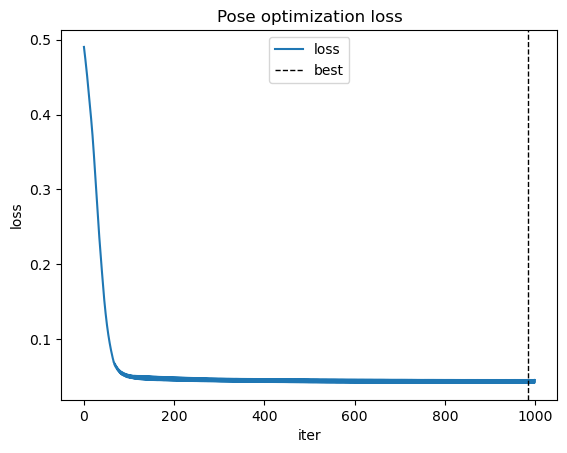

In [268]:
# Downsample ground-truth target frame to match training resolution
# (uses rgb1/depth1 loaded for frame1_idx)
gt_rgb1 = torch.from_numpy(rgb1).to(device).float().mul_(1.0 / 255.0)
gt_rgb1 = F.interpolate(
    gt_rgb1.permute(2, 0, 1).unsqueeze(0),
    size=(gs.train_height, gs.train_width),
    mode="bilinear",
    align_corners=False,
).squeeze(0).permute(1, 2, 0)

gt_depth1 = torch.from_numpy(depth1).to(device).float().div_(float(pcd.depth_scale))
gt_depth1 = F.interpolate(
    gt_depth1.unsqueeze(0).unsqueeze(0),
    size=(gs.train_height, gs.train_width),
    mode="nearest",
).squeeze(0).squeeze(0)

print("POSE_UPDATE_MODE:", POSE_UPDATE_MODE)

# Build an initial pose guess by perturbing the GT pose (translation + rotation)
pose1_gt_t = torch.from_numpy(pose1_gt).to(device).float()
with torch.no_grad():
    init_xi = torch.tensor([0.10, -0.05, 0.05, 0.15, -0.05, 0.00], device=device, dtype=torch.float32)  # rad, m
    pose1_init_t = pose_from_delta(pose1_gt_t, init_xi, mode=POSE_UPDATE_MODE)
pose1_init = pose1_init_t.detach().cpu().numpy()

# Optimize a delta from the initial guess (SGD + early stop + LR anneal)
xi = torch.zeros(6, device=device, requires_grad=True)
lr = 3e-3
optimizer = torch.optim.SGD([xi], lr=lr, momentum=0.0)

max_iters = 1000
patience = 120
min_improve = 1e-5
bad_steps = 0
lr_decay = 0.5
min_lr = 3e-5

best_loss = float("inf")
best_xi = None
best_it = -1
loss_hist = []
best_hist = []
for it in range(max_iters):
    with torch.no_grad():
        xi.data = torch.nan_to_num(xi.data, nan=0.0, posinf=0.0, neginf=0.0)
        xi.data.clamp_(-1.5, 1.5)

    pose_t = pose_from_delta(pose1_init_t, xi, mode=POSE_UPDATE_MODE)
    if not torch.isfinite(pose_t).all():
        print("Non-finite pose, resetting xi.")
        with torch.no_grad():
            xi.zero_()
        continue

    pred_rgb, pred_depth = render_rgbd_from_pose(pose_t)
    pred_rgb = torch.nan_to_num(pred_rgb, nan=0.0, posinf=1.0, neginf=0.0).clamp_(0.0, 1.0)

    # Masked photometric loss: only where the renderer actually produced geometry (depth > 0)
    rgb_loss = torch.zeros((), device=device)
    mask = None
    if pred_depth is not None:
        pred_depth = torch.nan_to_num(pred_depth, nan=0.0, posinf=0.0, neginf=0.0)
        mask = (pred_depth > 0.0) & torch.isfinite(pred_depth)

    if (mask is None) or (not mask.any()):
        rgb_loss = F.smooth_l1_loss(pred_rgb, gt_rgb1, beta=0.02)
    else:
        rgb_loss = F.smooth_l1_loss(pred_rgb[mask], gt_rgb1[mask], beta=0.02)

    # Depth loss (masked by both GT and predicted validity)
    depth_loss = torch.zeros((), device=device)
    if pred_depth is not None:
        valid = (gt_depth1 > 0.0) & torch.isfinite(gt_depth1) & (pred_depth > 0.0) & torch.isfinite(pred_depth)
        if valid.any():
            depth_loss = F.smooth_l1_loss(pred_depth[valid], gt_depth1[valid], beta=gs.depth_huber_delta)

    reg_loss = 5e-5 * (xi * xi).sum()
    loss = rgb_loss + 4 *depth_loss + reg_loss
    if not torch.isfinite(loss):
        print(f"Non-finite loss at iter {it+1}, resetting xi.")
        with torch.no_grad():
            xi.zero_()
        continue

    optimizer.zero_grad()
    loss.backward()

    if xi.grad is not None:
        xi.grad.data = torch.nan_to_num(xi.grad.data, nan=0.0, posinf=0.0, neginf=0.0)
    torch.nn.utils.clip_grad_norm_([xi], max_norm=1.0)
    optimizer.step()

    loss_val = float(loss.item())
    loss_hist.append(loss_val)
    best_hist.append(best_loss)

    improved = (best_loss - loss_val) > min_improve
    if improved:
        best_loss = loss_val
        best_xi = xi.detach().clone()
        best_it = it
        bad_steps = 0
    else:
        bad_steps += 1

    # Anneal + early stop: prevents the common "drop then drift back up" behavior
    if bad_steps >= patience:
        if lr > min_lr:
            lr = max(min_lr, lr * lr_decay)
            for pg in optimizer.param_groups:
                pg['lr'] = lr
            bad_steps = 0
            if best_xi is not None:
                with torch.no_grad():
                    xi.copy_(best_xi)
            print(f"anneal at iter {it+1}: lr -> {lr:.2e} (restore best)")
        else:
            print(f"early stop at iter {it+1}: no improvement; lr={lr:.2e}")
            break

    if (it + 1) % 20 == 0:
        grad_norm = float(xi.grad.norm().detach().cpu()) if xi.grad is not None else 0.0
        grad_rot = float(xi.grad[:3].norm().detach().cpu()) if xi.grad is not None else 0.0
        grad_trans = float(xi.grad[3:].norm().detach().cpu()) if xi.grad is not None else 0.0
        rot_norm = float(xi[:3].detach().norm().cpu())
        trans_norm = float(xi[3:].detach().norm().cpu())
        nmask = int(mask.sum().detach().cpu()) if (mask is not None and mask.any()) else 0
        print(
            f"iter {it+1:04d} | loss {loss_val:.5f} (best {best_loss:.5f}@{best_it+1}) | rgb {rgb_loss.item():.5f} | depth {depth_loss.item():.5f} | "
            f"mask {nmask} | |xi_rot| {rot_norm:.3e} |xi_trans| {trans_norm:.3e} | "
            f"|g_rot| {grad_rot:.3e} |g_trans| {grad_trans:.3e} | grad {grad_norm:.3e} | lr {lr:.1e}"
        )

# Restore best found (always evaluate best, not the last iterate)
if best_xi is not None:
    with torch.no_grad():
        xi.copy_(best_xi)

if loss_hist:
    print("loss start/best/end:", loss_hist[0], best_loss, loss_hist[-1])
    plt.plot(loss_hist, label="loss")
    if best_it >= 0:
        plt.axvline(best_it, color="k", linestyle="--", linewidth=1, label="best")
    plt.title("Pose optimization loss")
    plt.xlabel("iter")
    plt.ylabel("loss")
    plt.legend()
    plt.show()

In [269]:
# Diagnostic: check whether rotation/translation get nonzero gradients at init
xi_dbg = torch.zeros(6, device=device, requires_grad=True)
pose_dbg = pose_from_delta(pose1_init_t, xi_dbg)
pred_rgb_dbg, pred_depth_dbg = render_rgbd_from_pose(pose_dbg)
pred_rgb_dbg = torch.nan_to_num(pred_rgb_dbg, nan=0.0, posinf=1.0, neginf=0.0).clamp(0.0, 1.0)

mask_dbg = None
if pred_depth_dbg is not None:
    pred_depth_dbg = torch.nan_to_num(pred_depth_dbg, nan=0.0, posinf=0.0, neginf=0.0)
    mask_dbg = (pred_depth_dbg > 0.0) & torch.isfinite(pred_depth_dbg)

if (mask_dbg is None) or (not mask_dbg.any()):
    rgb_loss_dbg = F.smooth_l1_loss(pred_rgb_dbg, gt_rgb1, beta=0.02)
else:
    rgb_loss_dbg = F.smooth_l1_loss(pred_rgb_dbg[mask_dbg], gt_rgb1[mask_dbg], beta=0.02)

depth_loss_dbg = torch.zeros((), device=device)
if pred_depth_dbg is not None:
    valid_dbg = (gt_depth1 > 0.0) & torch.isfinite(gt_depth1) & (pred_depth_dbg > 0.0) & torch.isfinite(pred_depth_dbg)
    if valid_dbg.any():
        depth_loss_dbg = F.smooth_l1_loss(pred_depth_dbg[valid_dbg], gt_depth1[valid_dbg], beta=gs.depth_huber_delta)

loss_dbg = rgb_loss_dbg + gs.depth_loss_weight * depth_loss_dbg
loss_dbg.backward()

print("dbg loss:", float(loss_dbg.item()))
print("dbg mask px:", int(mask_dbg.sum().detach().cpu()) if (mask_dbg is not None and mask_dbg.any()) else 0)
print("dbg grad rot:", xi_dbg.grad[:3].detach().cpu().numpy())
print("dbg grad trans:", xi_dbg.grad[3:].detach().cpu().numpy())
print("dbg |g_rot|, |g_trans|:", float(xi_dbg.grad[:3].norm().detach().cpu()), float(xi_dbg.grad[3:].norm().detach().cpu()))

dbg loss: 0.13247577846050262
dbg mask px: 85074
dbg grad rot: [ 0.37157962 -1.1900296   0.8133019 ]
dbg grad trans: [ 0.18053736 -0.10766289 -0.25104147]
dbg |g_rot|, |g_trans|: 1.4885234832763672 0.3274245858192444


In [242]:
# Diagnostic: does a small step along -grad decrease the loss?
with torch.no_grad():
    g = xi_dbg.grad.detach().clone()
    g = torch.nan_to_num(g, nan=0.0, posinf=0.0, neginf=0.0)

def eval_loss_at_xi(xi_vec):
    pose = pose_from_delta(pose1_init_t, xi_vec)
    pred_rgb, pred_depth = render_rgbd_from_pose(pose)
    pred_rgb = torch.nan_to_num(pred_rgb, nan=0.0, posinf=1.0, neginf=0.0).clamp(0.0, 1.0)
    mask = None
    if pred_depth is not None:
        pred_depth = torch.nan_to_num(pred_depth, nan=0.0, posinf=0.0, neginf=0.0)
        mask = (pred_depth > 0.0) & torch.isfinite(pred_depth)
    if (mask is None) or (not mask.any()):
        rgb_loss = F.smooth_l1_loss(pred_rgb, gt_rgb1, beta=0.02)
    else:
        rgb_loss = F.smooth_l1_loss(pred_rgb[mask], gt_rgb1[mask], beta=0.02)
    depth_loss = torch.zeros((), device=device)
    if pred_depth is not None:
        valid = (gt_depth1 > 0.0) & torch.isfinite(gt_depth1) & (pred_depth > 0.0) & torch.isfinite(pred_depth)
        if valid.any():
            depth_loss = F.smooth_l1_loss(pred_depth[valid], gt_depth1[valid], beta=gs.depth_huber_delta)
    return float((rgb_loss + gs.depth_loss_weight * depth_loss).detach().cpu())

base = eval_loss_at_xi(torch.zeros(6, device=device))
print("base loss:", base)
for a in [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]:
    xi_try = (-a * g).detach()
    l_try = eval_loss_at_xi(xi_try)
    print(f"alpha {a:.0e} | loss {l_try:.6f} | d {l_try-base:+.6f} | |xi_try| {float(xi_try.norm().cpu()):.3e}")

base loss: 0.12683147192001343
alpha 1e-05 | loss 0.126811 | d -0.000020 | |xi_try| 1.536e-05
alpha 3e-05 | loss 0.126800 | d -0.000032 | |xi_try| 4.607e-05
alpha 1e-04 | loss 0.126744 | d -0.000088 | |xi_try| 1.536e-04
alpha 3e-04 | loss 0.126568 | d -0.000264 | |xi_try| 4.607e-04
alpha 1e-03 | loss 0.125877 | d -0.000954 | |xi_try| 1.536e-03
alpha 3e-03 | loss 0.123774 | d -0.003057 | |xi_try| 4.607e-03


In [243]:
# Diagnostic: one Adam step from xi=0
def compute_loss_for_xi(xi_vec):
    pose = pose_from_delta(pose1_init_t, xi_vec)
    pred_rgb, pred_depth = render_rgbd_from_pose(pose)
    pred_rgb = torch.nan_to_num(pred_rgb, nan=0.0, posinf=1.0, neginf=0.0).clamp(0.0, 1.0)
    mask = None
    if pred_depth is not None:
        pred_depth = torch.nan_to_num(pred_depth, nan=0.0, posinf=0.0, neginf=0.0)
        mask = (pred_depth > 0.0) & torch.isfinite(pred_depth)
    if (mask is None) or (not mask.any()):
        rgb_loss = F.smooth_l1_loss(pred_rgb, gt_rgb1, beta=0.02)
    else:
        rgb_loss = F.smooth_l1_loss(pred_rgb[mask], gt_rgb1[mask], beta=0.02)
    depth_loss = torch.zeros((), device=device)
    if pred_depth is not None:
        valid = (gt_depth1 > 0.0) & torch.isfinite(gt_depth1) & (pred_depth > 0.0) & torch.isfinite(pred_depth)
        if valid.any():
            depth_loss = F.smooth_l1_loss(pred_depth[valid], gt_depth1[valid], beta=gs.depth_huber_delta)
    reg_loss = 5e-5 * (xi_vec * xi_vec).sum()
    return rgb_loss + gs.depth_loss_weight * depth_loss + reg_loss

xi_tmp = torch.zeros(6, device=device, requires_grad=True)
opt_tmp = torch.optim.Adam([xi_tmp], lr=5e-4)
loss0 = compute_loss_for_xi(xi_tmp)
opt_tmp.zero_grad()
loss0.backward()
print("adam dbg | loss0:", float(loss0.item()))
print("adam dbg | grad rot/trans:", float(xi_tmp.grad[:3].norm().cpu()), float(xi_tmp.grad[3:].norm().cpu()))
opt_tmp.step()
with torch.no_grad():
    loss1 = compute_loss_for_xi(xi_tmp)
print("adam dbg | loss1:", float(loss1.item()), "delta:", float(loss1.item() - loss0.item()))
print("adam dbg | xi_tmp:", xi_tmp.detach().cpu().numpy())

adam dbg | loss0: 0.12683147192001343
adam dbg | grad rot/trans: 1.498785138130188 0.33440157771110535
adam dbg | loss1: 0.12623289227485657 delta: -0.0005985796451568604
adam dbg | xi_tmp: [-0.0005  0.0005 -0.0005 -0.0005  0.0005  0.0005]


In [244]:
# Diagnostic: one SGD step from xi=0 (plain gradient descent)
for lr in [3e-4, 1e-3, 3e-3]:
    xi_sgd = torch.zeros(6, device=device, requires_grad=True)
    opt_sgd = torch.optim.SGD([xi_sgd], lr=lr, momentum=0.0)
    l0 = compute_loss_for_xi(xi_sgd)
    opt_sgd.zero_grad()
    l0.backward()
    opt_sgd.step()
    with torch.no_grad():
        l1 = compute_loss_for_xi(xi_sgd)
    print(f"sgd dbg | lr {lr:.0e} | loss0 {float(l0.item()):.6f} -> loss1 {float(l1.item()):.6f} | d {float(l1.item()-l0.item()):+.6f} | |xi| {float(xi_sgd.norm().cpu()):.3e}")

sgd dbg | lr 3e-04 | loss0 0.126831 -> loss1 0.126568 | d -0.000264 | |xi| 4.607e-04
sgd dbg | lr 1e-03 | loss0 0.126831 -> loss1 0.125877 | d -0.000954 | |xi| 1.536e-03
sgd dbg | lr 3e-03 | loss0 0.126831 -> loss1 0.123774 | d -0.003057 | |xi| 4.607e-03


init error: 0.2632 m, 7.017 deg
opt  error: 0.0073 m, 0.220 deg


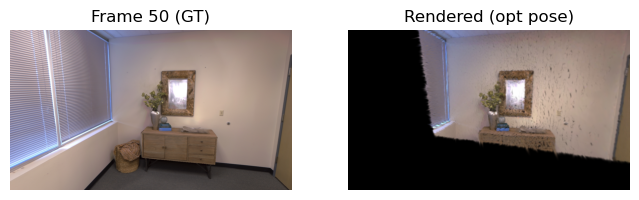

In [270]:
# Compare optimized pose to ground truth (evaluate BEST pose, not last iterate)
with torch.no_grad():
    pose1_opt = pose_from_delta(pose1_init_t, xi, mode=POSE_UPDATE_MODE).cpu().numpy()

def pose_errors(pose_pred, pose_gt):
    if not np.isfinite(pose_pred).all():
        return float("nan"), float("nan")
    t_err = np.linalg.norm(pose_pred[:3, 3] - pose_gt[:3, 3])
    R_rel = pose_pred[:3, :3] @ pose_gt[:3, :3].T
    trace = np.clip((np.trace(R_rel) - 1.0) / 2.0, -1.0, 1.0)
    r_err = np.degrees(np.arccos(trace))
    return float(t_err), float(r_err)

t_init, r_init = pose_errors(pose1_init, pose1_gt)
t_opt, r_opt = pose_errors(pose1_opt, pose1_gt)

print(f"init error: {t_init:.4f} m, {r_init:.3f} deg")
print(f"opt  error: {t_opt:.4f} m, {r_opt:.3f} deg")

pred_rgb_opt, _ = render_rgbd_from_pose(torch.from_numpy(pose1_opt).to(device))
pred_rgb_opt = pred_rgb_opt.detach().cpu().numpy()

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(rgb1, cv2.COLOR_BGR2RGB))
plt.title(f"Frame {frame1_idx} (GT)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pred_rgb_opt[..., ::-1])
plt.title("Rendered (opt pose)")
plt.axis("off")
plt.show()

In [260]:
# Numerical comparison between optimized and ground-truth poses (single pose metrics)
import numpy as np

if np.isfinite(pose1_opt).all() and np.isfinite(pose1_gt).all():
    delta = pose1_opt @ np.linalg.inv(pose1_gt)
    R = delta[:3, :3]
    t = delta[:3, 3]

    # Translation errors
    trans_m = np.linalg.norm(t)
    tx, ty, tz = float(t[0]), float(t[1]), float(t[2])

    # Rotation: axis-angle
    trace = np.clip((np.trace(R) - 1.0) / 2.0, -1.0, 1.0)
    angle_deg = float(np.degrees(np.arccos(trace)))

    # compute rotation axis (safe)
    s = float(np.sqrt((R[2,1] - R[1,2])**2 + (R[0,2] - R[2,0])**2 + (R[1,0] - R[0,1])**2))
    if (s < 1e-8) or (not np.isfinite(s)):
        axis = np.array([0.0, 0.0, 1.0], dtype=np.float32)
    else:
        axis = np.array(
            [R[2,1] - R[1,2], R[0,2] - R[2,0], R[1,0] - R[0,1]],
            dtype=np.float32,
        ) / (2.0 * s)

    frob = float(np.linalg.norm(delta - np.eye(4)))
    abs_err = np.abs(pose1_opt - pose1_gt)

    print(f"delta translation (norm): {trans_m:.6f} m")
    print(f"delta translation (xyz):  {tx:.6f}, {ty:.6f}, {tz:.6f} m")
    print(f"delta rotation (angle):   {angle_deg:.6f} deg")
    print(f"delta rotation (axis):    [{axis[0]:.6f}, {axis[1]:.6f}, {axis[2]:.6f}]")
    print(f"delta frob:               {frob:.6f}")
    print(f"abs error mean:           {abs_err.mean():.6e}")
    print(f"abs error max:            {abs_err.max():.6e}")

    # Reprojection pixel error of map points (optional, sampled)
    if getattr(pcd, 'all_points', None) is not None:
        pts_world = pcd.all_points.detach().cpu().numpy()
        if pts_world.ndim == 2 and pts_world.shape[1] >= 3 and pts_world.shape[0] > 0:
            n_samples = min(5000, pts_world.shape[0])
            idx = np.random.choice(pts_world.shape[0], n_samples, replace=False)
            sample = pts_world[idx, :3].astype(np.float32)

            # camera intrinsics
            fx = float(pcd.rgb_fx.cpu())
            fy = float(pcd.rgb_fy.cpu())
            cx = float(pcd.rgb_cx.cpu())
            cy = float(pcd.rgb_cy.cpu())

            # fixed rotation (3x3) -> homogeneous 4x4
            R_fix = np.asarray(pcd.R_fix.detach().cpu(), dtype=np.float32)
            if R_fix.shape != (3, 3):
                R_fix = np.eye(3, dtype=np.float32)
            T_fix = np.eye(4, dtype=np.float32)
            T_fix[:3, :3] = R_fix

            def project_points(pts, pose_w_c):
                pose_w_c = np.asarray(pose_w_c, dtype=np.float32)
                if pose_w_c.shape != (4, 4) or (not np.isfinite(pose_w_c).all()):
                    return None, None, None

                # pose_w_c: world_from_cam; apply RTSGS fixed rotation in world frame
                Twc = T_fix @ pose_w_c
                Tcw = np.linalg.inv(Twc)

                Pw = np.hstack([pts, np.ones((pts.shape[0], 1), dtype=np.float32)])
                Pc = (Tcw @ Pw.T).T

                z = Pc[:, 2]
                valid = z > 1e-6
                u = fx * (Pc[:, 0] / (z + 1e-12)) + cx
                v = fy * (Pc[:, 1] / (z + 1e-12)) + cy
                return u, v, valid

            u_opt, v_opt, valid_opt = project_points(sample, pose1_opt)
            u_gt, v_gt, valid_gt = project_points(sample, pose1_gt)

            if u_opt is None or u_gt is None:
                print("Reprojection skipped: invalid pose shape/values")
            else:
                valid = valid_opt & valid_gt & np.isfinite(u_opt) & np.isfinite(v_opt) & np.isfinite(u_gt) & np.isfinite(v_gt)
                if valid.any():
                    pix_err = np.sqrt((u_opt[valid] - u_gt[valid])**2 + (v_opt[valid] - v_gt[valid])**2)
                    print(f"reprojection count: {int(valid.sum())}/{n_samples}")
                    print(f"reprojection mean error: {pix_err.mean():.3f} px")
                    print(f"reprojection median error: {np.median(pix_err):.3f} px")
                    print(f"reprojection max error: {pix_err.max():.3f} px")
                else:
                    print("No valid reprojections for sampled map points.")
        else:
            print("Reprojection skipped: pcd.all_points has unexpected shape")
else:
    print("Pose contains non-finite values; cannot compute numeric comparison.")

delta translation (norm): 0.009483 m
delta translation (xyz):  0.002953, -0.004720, 0.007676 m
delta rotation (angle):   0.170174 deg
delta rotation (axis):    [0.334801, 0.081790, -0.362242]
delta frob:               0.010377
abs error mean:           1.428755e-03
abs error max:            8.042455e-03
reprojection count: 5000/5000
reprojection mean error: 3.661 px
reprojection median error: 2.278 px
reprojection max error: 53.278 px
